In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


 CSV READING AND CLEANING

In [2]:

folder_path = "Crops"
all_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

dataframes = []
for file in all_files:
    df = pd.read_csv(os.path.join(folder_path, file))
    crop_name = os.path.splitext(file)[0]  # e.g. apples.csv → apples
    df["Crop"] = crop_name
    dataframes.append(df)

combined_crops = pd.concat(dataframes, ignore_index=True)


In [3]:
combined_crops.head()


,Domain Code,Domain,Area Code (FAO),Area,Element Code,Element,Item Code (FAO),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Crop
0,QCL,Crops and livestock products,100,India,5312,Area harvested,515,Apples,1961,1961,ha,44500,F,FAO estimate,apples
1,QCL,Crops and livestock products,100,India,5312,Area harvested,515,Apples,1962,1962,ha,38500,F,FAO estimate,apples
2,QCL,Crops and livestock products,100,India,5312,Area harvested,515,Apples,1963,1963,ha,33700,F,FAO estimate,apples
3,QCL,Crops and livestock products,100,India,5312,Area harvested,515,Apples,1964,1964,ha,26500,F,FAO estimate,apples
4,QCL,Crops and livestock products,100,India,5312,Area harvested,515,Apples,1965,1965,ha,21700,F,FAO estimate,apples


In [4]:
combined_crops.tail()

,Domain Code,Domain,Area Code (FAO),Area,Element Code,Element,Item Code (FAO),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Crop
8521,QCL,Crops and livestock products,100,India,5510,Production,15,Wheat,2014,2014,tonnes,95850000,NaN,Official data,wheat
8522,QCL,Crops and livestock products,100,India,5510,Production,15,Wheat,2015,2015,tonnes,86530000,NaN,Official data,wheat
8523,QCL,Crops and livestock products,100,India,5510,Production,15,Wheat,2016,2016,tonnes,92290000,NaN,Official data,wheat
8524,QCL,Crops and livestock products,100,India,5510,Production,15,Wheat,2017,2017,tonnes,98510220,NaN,Official data,wheat
8525,QCL,Crops and livestock products,100,India,5510,Production,15,Wheat,2018,2018,tonnes,99869520,NaN,Official data,wheat


In [5]:
combined_crops.shape

(8526, 15)

In [6]:
combined_crops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8526 entries, 0 to 8525
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Domain Code       8526 non-null   object
 1   Domain            8526 non-null   object
 2   Area Code (FAO)   8526 non-null   int64 
 3   Area              8526 non-null   object
 4   Element Code      8526 non-null   int64 
 5   Element           8526 non-null   object
 6   Item Code (FAO)   8526 non-null   int64 
 7   Item              8526 non-null   object
 8   Year Code         8526 non-null   int64 
 9   Year              8526 non-null   int64 
 10  Unit              8526 non-null   object
 11  Value             8526 non-null   int64 
 12  Flag              4979 non-null   object
 13  Flag Description  8526 non-null   object
 14  Crop              8526 non-null   object
dtypes: int64(6), object(9)
memory usage: 999.3+ KB


In [7]:
combined_crops.describe

<bound method NDFrame.describe of      Domain Code                        Domain  Area Code (FAO)   Area  \
0            QCL  Crops and livestock products              100  India   
1            QCL  Crops and livestock products              100  India   
2            QCL  Crops and livestock products              100  India   
3            QCL  Crops and livestock products              100  India   
4            QCL  Crops and livestock products              100  India   
...          ...                           ...              ...    ...   
8521         QCL  Crops and livestock products              100  India   
8522         QCL  Crops and livestock products              100  India   
8523         QCL  Crops and livestock products              100  India   
8524         QCL  Crops and livestock products              100  India   
8525         QCL  Crops and livestock products              100  India   

      Element Code         Element  Item Code (FAO)    Item  Year Code  Year 

In [8]:
combined_crops.isnull().sum()

Domain Code            0
Domain                 0
Area Code (FAO)        0
Area                   0
Element Code           0
Element                0
Item Code (FAO)        0
Item                   0
Year Code              0
Year                   0
Unit                   0
Value                  0
Flag                3547
Flag Description       0
Crop                   0
dtype: int64

In [9]:
filtered_df=combined_crops[combined_crops['Element']=='Production']

In [10]:
filtered_df = filtered_df.drop(columns=[
    "Domain Code", "Area Code (FAO)", "Element Code",
    "Item Code (FAO)", "Year Code", "Flag", "Flag Description"
])


In [11]:
filtered_df=filtered_df.rename(columns={
    'Area':'Country',
    'Item':'Crop',
    'Value':'Production'})

In [12]:
filtered_df["Year"] = filtered_df["Year"].astype(int)
filtered_df["Production"] = pd.to_numeric(filtered_df["Production"], errors="coerce")
filtered_df.to_csv('combined_data.csv')


In [14]:
rainfall_df=pd.read_csv("Data/rainfall.csv")
temp_df=pd.read_csv('Data/temperature.csv')

In [15]:
rainfall_df.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,1961,26.1,34.8,26.0,28.5,77.6,192.9,336.6,287.6,234.9,122.2,21.7,10.4,1399.2,60.9,132.1,1052.0,154.2
1,1962,12.6,21.6,16.0,43.6,70.8,137.1,281.6,276.9,211.0,78.4,18.3,29.9,1198.0,34.3,130.4,906.6,126.7
2,1963,6.8,9.8,41.7,50.6,60.9,168.0,258.6,316.7,164.9,99.1,28.4,15.5,1220.9,16.6,153.1,908.2,142.9
3,1964,18.6,14.1,19.0,40.0,52.1,177.2,345.7,273.7,200.4,67.4,22.8,13.3,1244.4,32.7,111.1,997.0,103.5
4,1965,11.8,28.1,26.7,45.1,52.7,116.1,270.1,192.8,129.5,34.0,18.2,22.2,947.4,39.9,124.6,708.5,74.4


In [16]:
rainfall_df.info()
rainfall_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YEAR     58 non-null     int64  
 1   JAN      58 non-null     float64
 2   FEB      58 non-null     float64
 3   MAR      58 non-null     float64
 4   APR      58 non-null     float64
 5   MAY      58 non-null     float64
 6   JUN      58 non-null     float64
 7   JUL      58 non-null     float64
 8   AUG      58 non-null     float64
 9   SEP      58 non-null     float64
 10  OCT      58 non-null     float64
 11  NOV      58 non-null     float64
 12  DEC      58 non-null     float64
 13  ANN      58 non-null     float64
 14  Jan-Feb  58 non-null     float64
 15  Mar-May  58 non-null     float64
 16  Jun-Sep  58 non-null     float64
 17  Oct-Dec  58 non-null     float64
dtypes: float64(17), int64(1)
memory usage: 8.3 KB


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,1989.500000,16.815517,23.437931,28.877586,38.174138,62.256897,166.043103,282.324138,256.698276,168.686207,75.153448,29.127586,16.167241,1161.181034,40.244828,129.310345,873.760345,120.458621
std,16.886879,6.313000,9.214421,11.729600,9.665104,14.084857,31.419053,36.970900,31.682158,30.931166,24.939578,15.203552,9.597503,100.771220,11.144540,20.851090,83.836777,26.934632
min,1961.000000,1.700000,8.800000,8.800000,19.300000,31.700000,85.700000,146.200000,190.100000,114.200000,33.000000,10.700000,1.600000,947.100000,16.100000,90.500000,674.300000,65.800000
25%,1975.250000,12.625000,15.600000,20.350000,30.800000,53.100000,143.225000,262.200000,236.400000,145.400000,55.175000,18.200000,10.775000,1095.050000,32.800000,115.025000,822.775000,99.900000
50%,1989.500000,16.100000,24.000000,28.050000,37.500000,60.650000,169.000000,283.250000,261.450000,165.200000,72.250000,25.500000,15.000000,1170.450000,39.250000,124.800000,886.250000,123.800000
75%,2003.750000,20.475000,28.050000,35.500000,43.775000,70.000000,184.700000,304.625000,276.900000,190.550000,97.925000,35.500000,19.000000,1216.550000,46.600000,139.875000,913.800000,140.175000
max,2018.000000,31.300000,45.600000,63.300000,68.300000,112.900000,229.900000,374.800000,316.700000,251.600000,129.400000,76.100000,56.100000,1401.400000,69.900000,210.700000,1052.000000,167.400000


In [17]:
rainfall_df.isnull().sum()

YEAR       0
JAN        0
FEB        0
MAR        0
APR        0
MAY        0
JUN        0
JUL        0
AUG        0
SEP        0
OCT        0
NOV        0
DEC        0
ANN        0
Jan-Feb    0
Mar-May    0
Jun-Sep    0
Oct-Dec    0
dtype: int64

In [18]:

rainfall_df.rename(columns={'YEAR': 'Year'}, inplace=True)
temp_df.rename(columns={'YEAR': 'Year'}, inplace=True)


rainfall_cols = ["Year", "JAN", "FEB", "MAR", "APR", "MAY", "JUN",
                 "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
temperature_cols = ["Year", "ANNUAL", "JAN-FEB", "MAR-MAY", "JUN-SEP", "OCT-DEC"]

rain_df = rainfall_df[rainfall_cols]
temp_df = temp_df[temperature_cols]


rain_df = rain_df.add_prefix("Rain_")
temp_df = temp_df.add_prefix("Temp_")


rain_df.rename(columns={"Rain_Year": "Year"}, inplace=True)
temp_df.rename(columns={"Temp_Year": "Year"}, inplace=True)


climate_df = pd.merge(rain_df, temp_df, on="Year", how="inner")

final_df = pd.merge(combined_crops, climate_df, on="Year", how="left")

final_df.to_csv("merged_crop_climate.csv", index=False)

print("✅ Merged dataset created successfully!")
print(f"Shape: {final_df.shape}")
print("Columns:", final_df.columns.tolist()[:20], "...")


✅ Merged dataset created successfully!
Shape: (8526, 32)
Columns: ['Domain Code', 'Domain', 'Area Code (FAO)', 'Area', 'Element Code', 'Element', 'Item Code (FAO)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Crop', 'Rain_JAN', 'Rain_FEB', 'Rain_MAR', 'Rain_APR', 'Rain_MAY'] ...


In [19]:
merged_file=pd.read_csv("Data/merged_crop_climate.csv")

In [20]:
merged_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8526 entries, 0 to 8525
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       8526 non-null   object 
 1   Domain            8526 non-null   object 
 2   Area Code (FAO)   8526 non-null   int64  
 3   Area              8526 non-null   object 
 4   Element Code      8526 non-null   int64  
 5   Element           8526 non-null   object 
 6   Item Code (FAO)   8526 non-null   int64  
 7   Item              8526 non-null   object 
 8   Year Code         8526 non-null   int64  
 9   Year              8526 non-null   int64  
 10  Unit              8526 non-null   object 
 11  Value             8526 non-null   int64  
 12  Flag              4979 non-null   object 
 13  Flag Description  8526 non-null   object 
 14  Crop              8526 non-null   object 
 15  Rain_JAN          8526 non-null   float64
 16  Rain_FEB          8526 non-null   float64


In [21]:
final_merged_dataset=merged_file.drop(columns=["Domain Code", "Area Code (FAO)", "Element Code",
    "Item Code (FAO)", "Year Code", "Flag", "Flag Description"])


In [25]:
final_merged_dataset.to_csv('Data/merged_dataset.csv')

In [23]:
crop_yield_df=pd.read_csv('Data/crop_yield.csv')

In [24]:
crop_yield_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [26]:
merged_data=pd.read_csv("Data/merged_dataset.csv")

In [27]:
merged_data.rename(columns={'Year':'Crop_Year'},inplace=True)

In [28]:
final_merged=pd.merge(crop_yield_df,merged_data,on='Crop_Year',how='left')

In [29]:
final_merged.to_csv("Data/final_crop_climate_dataset.csv", index=False)

VISUALISING CSV

C:\Users\somay\AppData\Local\Temp\ipykernel_10632\877649953.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Crop_Year', y='Yield', ci=None)


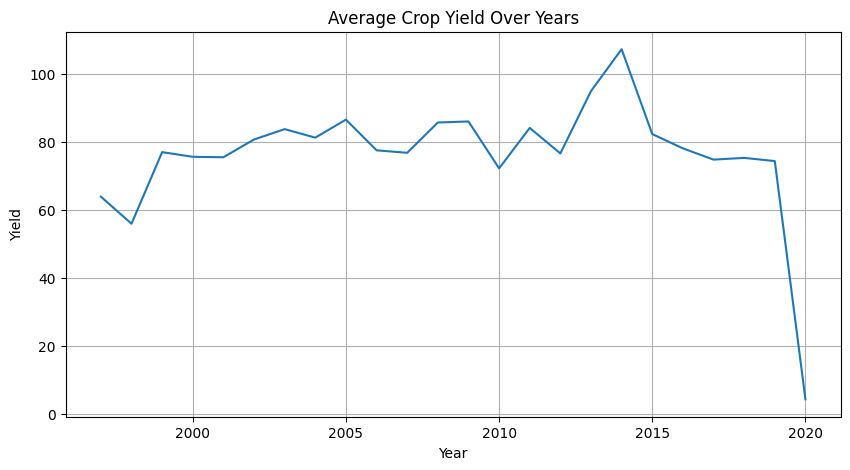

In [31]:

df = pd.read_csv("Data/final_crop_climate_dataset.csv")


# 4️⃣ Visualize yield over time
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Crop_Year', y='Yield', ci=None)
plt.title("Average Crop Yield Over Years")
plt.xlabel("Year")
plt.ylabel("Yield")
plt.grid(True)
plt.show()



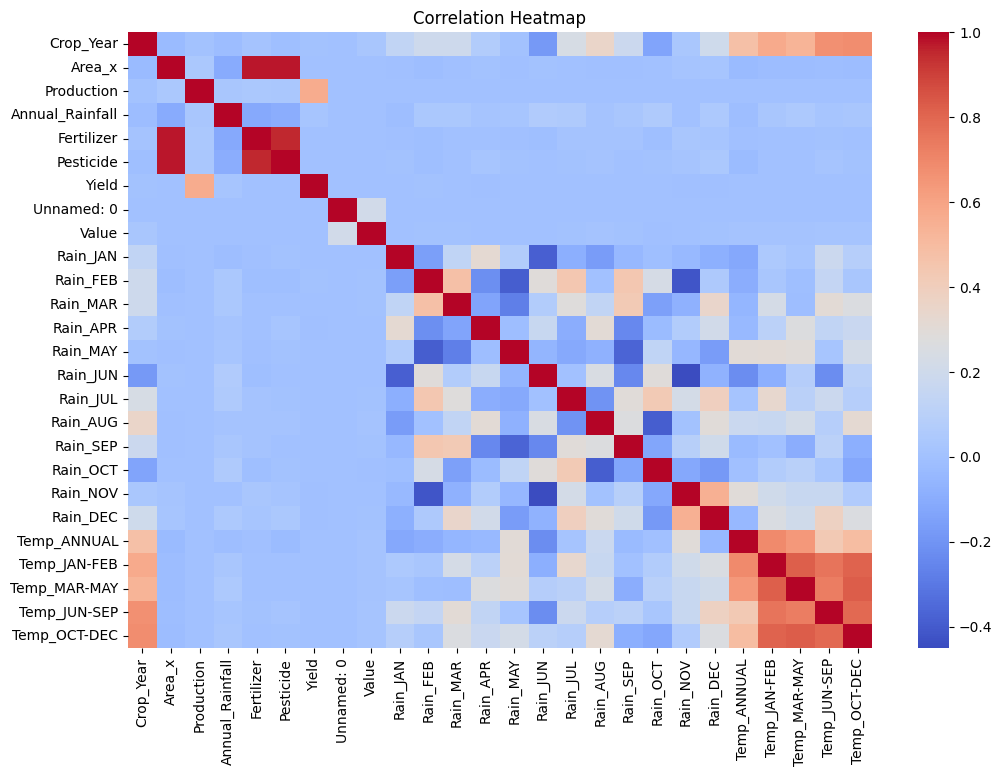

In [32]:
# 5️⃣ Correlation heatmap (to see relationships)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()



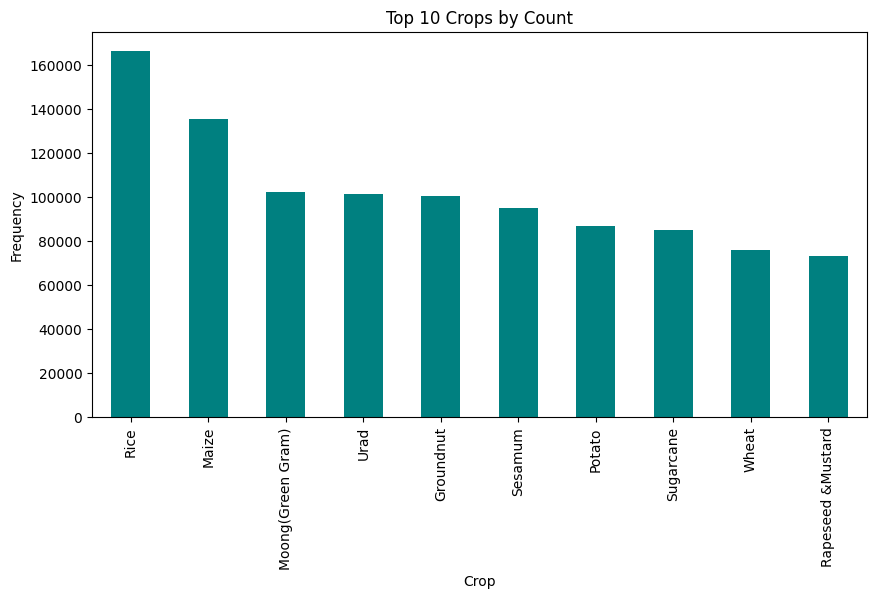

In [33]:
# 6️⃣ Check top crops
plt.figure(figsize=(10,5))
df['Crop_x'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title("Top 10 Crops by Count")
plt.xlabel("Crop")
plt.ylabel("Frequency")
plt.show()


In [34]:
df=pd.read_csv('Data/final_crop_climate_dataset.csv')

In [35]:

df = df.dropna(thresh=len(df.columns)//2)
# Drop irrelevant columns (adjust names if different)
drop_cols = ['Flag', 'Element Code', 'Element', 'Unit', 'Indicator', 'Country', 'Area'] 
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

print("✅ Columns after dropping:", df.columns.tolist())



for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("✅ Missing values handled successfully.")


✅ Columns after dropping: ['Crop_x', 'Crop_Year', 'Season', 'State', 'Area_x', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'Unnamed: 0', 'Domain', 'Area_y', 'Item', 'Value', 'Crop_y', 'Rain_JAN', 'Rain_FEB', 'Rain_MAR', 'Rain_APR', 'Rain_MAY', 'Rain_JUN', 'Rain_JUL', 'Rain_AUG', 'Rain_SEP', 'Rain_OCT', 'Rain_NOV', 'Rain_DEC', 'Temp_ANNUAL', 'Temp_JAN-FEB', 'Temp_MAR-MAY', 'Temp_JUN-SEP', 'Temp_OCT-DEC']


C:\Users\somay\AppData\Local\Temp\ipykernel_10632\327120038.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\somay\AppData\Local\Temp\ipykernel_10632\327120038.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

✅ Missing values handled successfully.


In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

    

In [38]:

temp_cols = [col for col in df.columns if 'Temp_' in col]
df['Avg_Temperature'] = df[temp_cols].mean(axis=1)

rain_cols = [col for col in df.columns if 'Rain_' in col]
df['Total_Rainfall'] = df[rain_cols].sum(axis=1)
df['Rain_Temp_Ratio'] = df['Total_Rainfall'] / (df['Avg_Temperature'] + 1)

print("✅ Derived features created.")


✅ Derived features created.


In [39]:
df.to_csv('Data/preprocessed_data.csv',index=False)

MODEL TRAINING


In [40]:
df=pd.read_csv('Data/preprocessed_data.csv')

In [41]:
df = df.drop_duplicates()
df = df.dropna(subset=['Yield']).reset_index(drop=True)

In [42]:
leak_cols = ['Area', 'Area_x', 'Area_y', 'Production']
df = df.drop(columns=[col for col in leak_cols if col in df.columns], errors='ignore')


In [44]:
features = ["State", "Crop_Year", "Season", "Fertilizer", "Pesticide", "Annual_Rainfall","Crop_x"]
target = "Yield"


In [45]:
df = df[features + [target]].dropna()
print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

✅ Dataset loaded successfully
Shape: (2730231, 8)
Columns: ['State', 'Crop_Year', 'Season', 'Fertilizer', 'Pesticide', 'Annual_Rainfall', 'Crop_x', 'Yield']
   State  Crop_Year  Season  Fertilizer  Pesticide  Annual_Rainfall  Crop_x  \
0      2       1997       4  7024878.38   22882.34           2051.4       0   
1      2       1997       4  7024878.38   22882.34           2051.4       0   
2      2       1997       4  7024878.38   22882.34           2051.4       0   
3      2       1997       4  7024878.38   22882.34           2051.4       0   
4      2       1997       4  7024878.38   22882.34           2051.4       0   

      Yield  
0  0.796087  
1  0.796087  
2  0.796087  
3  0.796087  
4  0.796087  


In [46]:
label_encoders = {}
for col in ["State", "Season","Crop_x"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le



In [47]:
X = df[features]
y = df[target]

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_cols = ["Fertilizer", "Pesticide", "Annual_Rainfall"]
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

In [49]:
X = df[features]
y = df[target]
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    


In [50]:
print(x_train.shape)
print(y_train.shape)

(2184184, 7)
(2184184,)


RANDOMFORESTREGRESSOR,
XGBOOST


In [ ]:
!pip install xgboost

In [51]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(x_train,y_train)



,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None



📊 XGBoost Performance:
R² Score: 0.9997
MAE: 5.9464
RMSE: 15.3940


C:\Users\somay\AppData\Local\Temp\ipykernel_10632\3434404281.py:35: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\somay\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


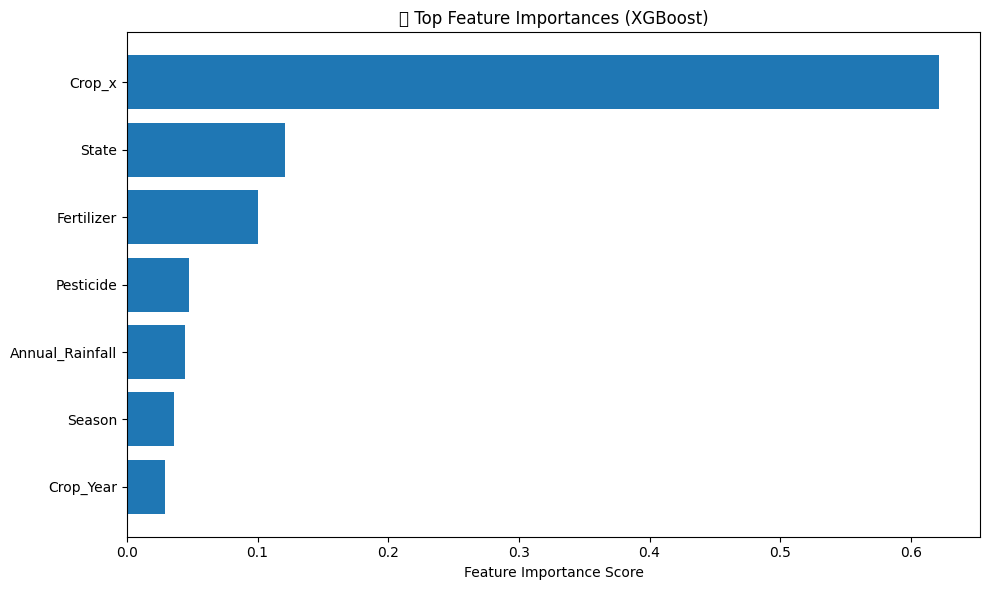

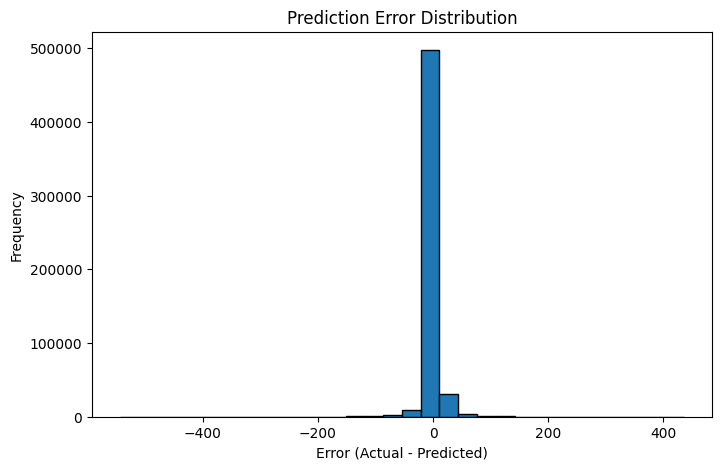


📈 Min Yield: 0.00
📈 Max Yield: 21105.00
📈 Average Yield: 80.43


In [53]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(model, x_test, y_test, name="Model"):
    """Evaluate regression model and print key performance metrics."""
    y_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n📊 {name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return y_pred, r2, mae, rmse


y_pred, r2, mae, rmse = evaluate_model(xgb, x_test, y_test, "XGBoost")

# ======================
# 7️⃣ Feature Importance Plot
# ======================

importances = xgb.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("🌾 Top Feature Importances (XGBoost)")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

# ======================
# 8️⃣ Error Distribution Plot
# ======================

errors = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30, edgecolor='black')
plt.title("Prediction Error Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

# ======================
# 9️⃣ Print Yield Range for Reference
# ======================

print(f"\n📈 Min Yield: {df['Yield'].min():.2f}")
print(f"📈 Max Yield: {df['Yield'].max():.2f}")
print(f"📈 Average Yield: {df['Yield'].mean():.2f}")

In [ ]:
import joblib
joblib.dump(xgb, "app/xgb_crop_yield_model.pkl")  # Save inside app folder



In [57]:
from sklearn.preprocessing import LabelEncoder
import joblib

state_encoder = LabelEncoder()
df['State'] = state_encoder.fit_transform(df['State'])
joblib.dump(state_encoder, 'app/state_encoder.pkl')



['app/state_encoder.pkl']

In [58]:
season_encoder=LabelEncoder()
df['Season']=season_encoder.fit_transform(df['Season'])
joblib.dump(season_encoder,'app/season_encoder.pkl')



['app/season_encoder.pkl']

In [59]:
crop_encoder=LabelEncoder()
df['Crop_x']=crop_encoder.fit_transform(df['Crop_x'])
joblib.dump(crop_encoder,'app/crop_encoder.pkl')

['app/crop_encoder.pkl']